# 04 — Cleaning and network-wide fault flagging

Apply the Byrne (2023) quality rule (imported from `src/cleaning.py`) to every sensor. Flags rows rather than deleting them. Produces per-sensor cleaned Parquet in `data/processed/cleaned/`, a network cleaning summary, and a fault-candidate table sorted by A/B disagreement — the first deliverable for the fault-detection objective.

The summary separates **high-band** A/B disagreement (likely genuine hardware fault) from **low-band** disagreement (noise-prone near-clean air), so the ranking isn't distorted by threshold artefacts at low concentrations.

In [11]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # so `from src...` works from notebooks/
from src.config import *
import pandas as pd
import numpy as np
from src.cleaning import clean_sensor

# two contrasting sensors to sanity-check the rule before the batch
sl001 = pd.read_parquet(PROCESSED / "SL001_Sunnyview_Terrace.parquet")
sl026 = pd.read_parquet(PROCESSED / "SL026.parquet")
sl030 = pd.read_parquet(PROCESSED / "SL030.parquet")
print("SL001:", len(sl001), "  SL026:", len(sl026), "  SL030:", len(sl030))

SL001: 1038078   SL026: 932711   SL030: 12491


### Duplicate-timestamp check
Understand whether repeated timestamps exist before relying on `drop_duplicates`.

In [12]:
def duplicate_report(df, name):
    full_dups = df.duplicated(keep=False).sum()
    ts_dups   = df.duplicated(subset=[DATE_COL], keep=False).sum()
    print(f"=== {name} ===")
    print(f"  total rows:            {len(df):,}")
    print(f"  fully identical rows:  {full_dups:,}")
    print(f"  duplicated timestamps: {ts_dups:,}\n")

for nm, d in [("SL001", sl001), ("SL026", sl026), ("SL030", sl030)]:
    duplicate_report(d, nm)

=== SL001 ===
  total rows:            1,038,078
  fully identical rows:  49
  duplicated timestamps: 49

=== SL026 ===
  total rows:            932,711
  fully identical rows:  0
  duplicated timestamps: 0

=== SL030 ===
  total rows:            12,491
  fully identical rows:  0
  duplicated timestamps: 0



### Sanity-check the rule on the three samples
`clean_sensor` is defined once in `src/cleaning.py` and imported — the notebook never redefines it.

In [13]:
for name, df_raw in [("SL001", sl001), ("SL026", sl026), ("SL030", sl030)]:
    cleaned, n_dups = clean_sensor(df_raw)
    n, clean_n = len(cleaned), cleaned["is_clean"].sum()
    print(f"=== {name} ===")
    print(f"  duplicates removed:    {n_dups:,}")
    print(f"  flagged implausible:   {cleaned['flag_implausible'].sum():,}")
    print(f"  flagged A/B disagree:  {cleaned['flag_ab'].sum():,}")
    print(f"  CLEAN rows:            {clean_n:,} / {n:,}  ({clean_n/n*100:.1f}%)")
    raw_max   = df_raw[PM_A].max()
    clean_max = cleaned.loc[cleaned["is_clean"], PM_A].max()
    print(f"  PM2.5 A max:  raw {raw_max:.1f}  ->  clean {clean_max:.1f}\n")

=== SL001 ===
  duplicates removed:    38
  flagged implausible:   173,199
  flagged A/B disagree:  599,972
  CLEAN rows:            438,067 / 1,038,040  (42.2%)
  PM2.5 A max:  raw 3402.1  ->  clean 731.3

=== SL026 ===
  duplicates removed:    0
  flagged implausible:   0
  flagged A/B disagree:  521,052
  CLEAN rows:            411,659 / 932,711  (44.1%)
  PM2.5 A max:  raw 409.5  ->  clean 409.5

=== SL030 ===
  duplicates removed:    0
  flagged implausible:   0
  flagged A/B disagree:  4,138
  CLEAN rows:            8,353 / 12,491  (66.9%)
  PM2.5 A max:  raw 72.6  ->  clean 40.4



### Network-wide cleaning
Run the rule over every sensor Parquet, write cleaned copies, and build the summary + fault table. Paths come from `config` — no hardcoded absolute paths.

In [14]:
rows = []
sensor_files = sorted(PROCESSED.glob("*.parquet"))
print(f"found {len(sensor_files)} sensor files")

for path in sensor_files:
    name = path.stem
    df_raw = pd.read_parquet(path)
    if PM_A not in df_raw.columns or PM_B not in df_raw.columns:
        print(f"  ! {name}: missing PM columns, skipped"); continue

    cleaned, n_dups = clean_sensor(df_raw)
    cleaned.to_parquet(CLEANED / f"{name}.parquet", index=False)

    a, b   = cleaned[PM_A], cleaned[PM_B]
    higher = np.maximum(a, b)
    ab_high = (cleaned["flag_ab"] & (higher >  PM_BREAK)).sum()   # fault signal
    ab_low  = (cleaned["flag_ab"] & (higher <= PM_BREAK)).sum()   # noise-prone

    rows.append({
        "sensor": name, "rows": len(cleaned), "duplicates": n_dups,
        "n_implausible": int(cleaned["flag_implausible"].sum()),
        "n_ab_total":    int(cleaned["flag_ab"].sum()),
        "n_ab_highband": int(ab_high),
        "n_ab_lowband":  int(ab_low),
        "n_clean":       int(cleaned["is_clean"].sum()),
        "pct_clean":     round(cleaned["is_clean"].mean() * 100, 1),
        "pct_ab_flag":   round(cleaned["flag_ab"].mean() * 100, 1),
        "pm_a_max_raw":  round(df_raw[PM_A].max(), 1),
        "pm_a_max_clean":round(cleaned.loc[cleaned["is_clean"], PM_A].max(), 1),
    })
    print(f"  {name}: {len(cleaned):,} rows, {rows[-1]['pct_clean']}% clean")

found 47 sensor files
  SL001_Sunnyview_Terrace: 1,038,040 rows, 42.2% clean
  SL003_Corn_Exchange_Cabinet: 575,919 rows, 54.8% clean
  SL005_Kirkstall_Valley_Primary: 523,788 rows, 67.6% clean
  SL006: 1,031,335 rows, 58.9% clean
  SL007_Ninelands_Primary: 1,020,702 rows, 62.9% clean
  SL008_Westgate_Primary: 766,797 rows, 51.4% clean
  SL009: 168,047 rows, 63.8% clean
  SL011: 803,050 rows, 50.2% clean
  SL012_Morley: 934,506 rows, 72.0% clean
  SL015_-_Garforth_Main_Street: 417,632 rows, 71.0% clean
  SL016_Scholes_Main_Street: 719,270 rows, 74.7% clean
  SL018_East_Ardsley_A650: 632,321 rows, 35.5% clean
  SL019_Cornwall_Crescent_Rothwell: 735,362 rows, 71.7% clean
  SL020: 614,317 rows, 70.1% clean
  SL021_Kippax_Church_Lane: 576,790 rows, 53.2% clean
  SL022_Church_Lane_Horsforth: 507,381 rows, 71.6% clean
  SL023_Nelson_Street_Otley: 276,076 rows, 59.9% clean
  SL024_Wetherby_Town_Centre: 987,091 rows, 73.9% clean
  SL025_-_Oakwood: 944,507 rows, 57.4% clean
  SL026: 932,711 row

### Network summary + fault-candidate table
Sorted by A/B-disagreement rate. The `n_ab_highband` column is the honest fault signal.

In [15]:
summary = pd.DataFrame(rows).sort_values("pct_ab_flag", ascending=False)
summary.to_csv(OUT_TABLES / "cleaning_summary.csv", index=False)

print("=== fault candidates (highest A/B-disagree rate) ===")
print(summary[["sensor", "rows", "pct_ab_flag", "n_ab_highband",
               "pct_clean", "pm_a_max_raw"]].head(10).to_string(index=False))

=== fault candidates (highest A/B-disagree rate) ===
                 sensor    rows  pct_ab_flag  n_ab_highband  pct_clean  pm_a_max_raw
                  SL037  881161         86.6         729764       13.4        3407.9
SL018_East_Ardsley_A650  632321         64.5         197616       35.5        3398.8
SL001_Sunnyview_Terrace 1038040         57.8         344196       42.2        3402.1
                  SL026  932711         55.9         189222       44.1         409.5
                  SL062  623075         53.2          95976       46.8         606.2
                  SL034  579145         51.7         203955       48.3        3396.9
                  SL044  863374         51.1         258538       48.9        3394.8
                  SL011  803050         49.8         170200       50.2        1429.1
                  SL032  188838         49.4          38281       50.6         360.3
 SL008_Westgate_Primary  766797         48.6         172047       51.4        3333.0


In [ ]:
import pandas as pd
import numpy as np

# what counts as good coverage
EXPECTED_PER_HOUR = 30      # 60 min / 2-min interval = 30 readings per hour
HOURLY_MIN_FRAC   = 0.5     # an hour is "covered" if it has >=50% of expected readings

rows = []
for path in sorted(CLEANED.glob("*.parquet")):
    name  = path.stem
    df    = pd.read_parquet(path)
    clean = df[df["is_clean"]].copy()
    if clean.empty:
        continue
    clean[DATE_COL] = pd.to_datetime(clean[DATE_COL])

    ser = clean.set_index(DATE_COL)
    per_hour = ser[PM_A].resample("h").count()      # clean readings per hour

    rows.append({
        "sensor": name,
        "clean_rows": len(clean),
        "span_days": (clean[DATE_COL].max() - clean[DATE_COL].min()).days,
        "median_readings_per_hour": int(per_hour[per_hour > 0].median()),
        "pct_hours_well_covered": round(
            (per_hour >= EXPECTED_PER_HOUR * HOURLY_MIN_FRAC).mean() * 100, 1),
        "pct_rows_with_RH": round(clean[RH_COL].notna().mean() * 100, 1),
    })

cov = pd.DataFrame(rows).sort_values("pct_hours_well_covered", ascending=False)
cov.to_csv(OUT_TABLES / "coverage_check.csv", index=False)

print(cov.to_string(index=False))
print("\n--- network summary ---")
print(f"median % hours well-covered: {cov['pct_hours_well_covered'].median():.1f}%")
print(f"median % rows with RH:       {cov['pct_rows_with_RH'].median():.1f}%")
print(f"sensors with usable RH (>50%): {(cov['pct_rows_with_RH'] > 50).sum()} of {len(cov)}")

                          sensor  clean_rows  span_days  median_readings_per_hour  pct_hours_well_covered  pct_rows_with_RH
      SL024_Wetherby_Town_Centre      729618       1560                        25                    70.9             100.0
                    SL012_Morley      672597       1495                        24                    67.9             100.0
         SL007_Ninelands_Primary      641613       1573                        23                    60.2              99.0
                           SL035      410357       1096                        22                    59.0             100.0
    SL015_-_Garforth_Main_Street      296565        808                        23                    57.7             100.0
SL019_Cornwall_Crescent_Rothwell      527495       1400                        23                    57.7             100.0
        SL027_-_SEE_Building_new      593817       1557                        21                    55.9             100.0
        

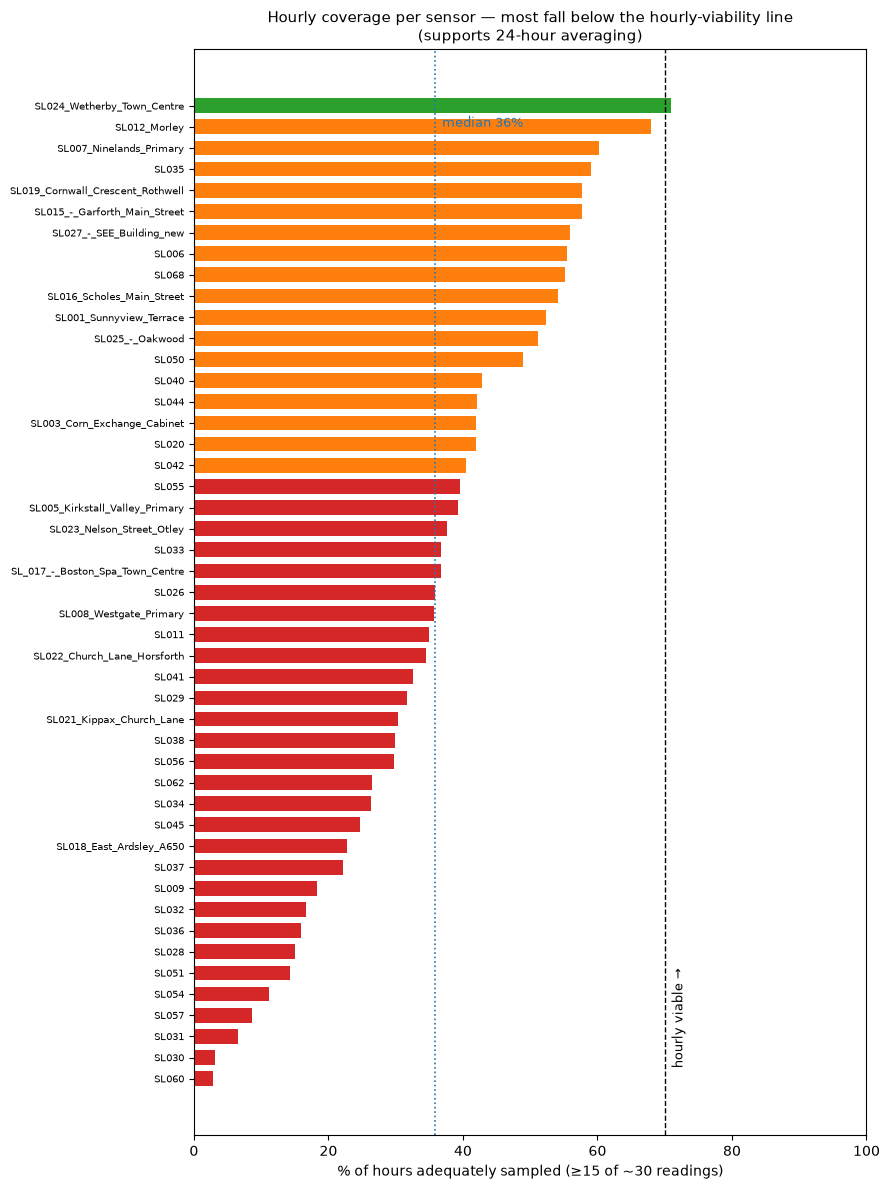

In [ ]:
import matplotlib.pyplot as plt

# plot coverage per sensor
cov = pd.read_csv(OUT_TABLES / "coverage_check.csv") 
cov = cov.sort_values("pct_hours_well_covered")

THRESHOLD = 70   # rough hourly-viability line
colors = ["tab:green" if v >= THRESHOLD else ("tab:orange" if v >= 40 else "tab:red")
          for v in cov["pct_hours_well_covered"]]

fig, ax = plt.subplots(figsize=(9, 12))
ax.barh(cov["sensor"], cov["pct_hours_well_covered"], color=colors, height=0.7)

ax.axvline(THRESHOLD, color="black", ls="--", lw=1)
ax.text(THRESHOLD + 1, 0.5, "hourly viable →", fontsize=9, rotation=90, va="bottom")

med = cov["pct_hours_well_covered"].median()
ax.axvline(med, color="tab:blue", ls=":", lw=1.2)
ax.text(med + 1, len(cov) - 2, f"median {med:.0f}%", fontsize=9, color="tab:blue")

ax.set_xlabel("% of hours adequately sampled (≥15 of ~30 readings)")
ax.set_title("Hourly coverage per sensor — most fall below the hourly-viability line\n"
             "(supports 24-hour averaging)", fontsize=11)
ax.set_xlim(0, 100)
ax.tick_params(axis="y", labelsize=7)
plt.tight_layout()
plt.savefig(OUT_FIGURES / "coverage_per_sensor.png", dpi=150, bbox_inches="tight")
plt.show()